In [1]:
import numpy as np
from kernelcpd import binseg
import matplotlib.pyplot as plt
import ruptures as rpt

np.random.seed(1234)

### GROUND TRUTH (Choose one)

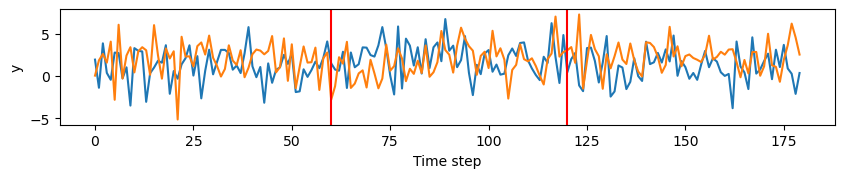

In [2]:
# sample signal, 3 segments, 2 changepoints at index 29 and 59
seg_len = 60 # segment length
signal1 = np.column_stack((np.random.normal(1.0, 2.0, seg_len), np.random.normal(2.0, 2.0, seg_len)))
signal2 = np.column_stack((np.random.normal(2.0, 2.0, seg_len), np.random.normal(1.5, 2.0, seg_len)))
signal3 = np.column_stack((np.random.normal(1.0, 2.0, seg_len), np.random.normal(2.0, 2.0, seg_len)))
y = np.vstack((signal1, signal2, signal3))

bkps = [seg_len, 2*seg_len]

plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in bkps:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

In [3]:
# n_samples = 200
# bkps = [100]
# res = np.zeros(n_samples)
# # Segment 1: High positive correlation
# phi1 = [0.9]
# # Segment 2: High negative correlation (oscillatory)
# phi2 = [-0.9]

# noise = np.random.normal(0, 0.1, n_samples)

# for t in range(1, n_samples):
#     if t < bkps[0]:
#         res[t] = phi1[0] * res[t-1] + noise[t]
#     else:
#         res[t] = phi2[0] * res[t-1] + noise[t]

# y = res.reshape(-1,1)

# plt.figure(figsize=(10, 1.5))
# for i in range(y.shape[1]):
#     plt.plot(y[:, i])
# for j in bkps:
#     plt.axvline(x = j, color='red')
# plt.xlabel("Time step")
# plt.ylabel("y")
# plt.show()

In [4]:
# t = np.arange(200)
# y = np.where(t<100, np.sin(2*np.pi*t*40/200), np.sin(2*np.pi*t*50/200)).reshape(-1,1)
# y = y + np.random.normal(0, 0.8, 200).reshape(-1,1)

# bkps = [100]

# plt.figure(figsize=(10, 1.5))
# for i in range(y.shape[1]):
#     plt.plot(y[:, i])
# for j in bkps:
#     plt.axvline(x = j, color='red')
# plt.xlabel("Time step")
# plt.ylabel("y")
# plt.show()

### CHOOSE ONE METHOD

[ 54 129]


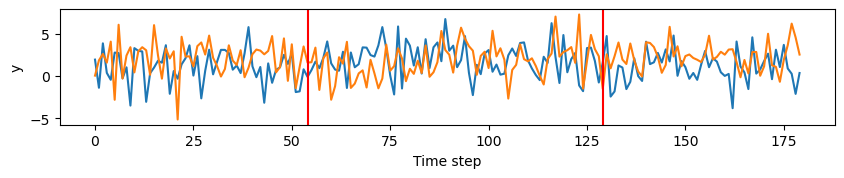

In [5]:
# detection
algo = rpt.Binseg(model="rbf").fit(y)
traditional_chpnts = np.array(algo.predict(n_bkps=2)[:-1]) - 1

print(traditional_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in traditional_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[146 168]


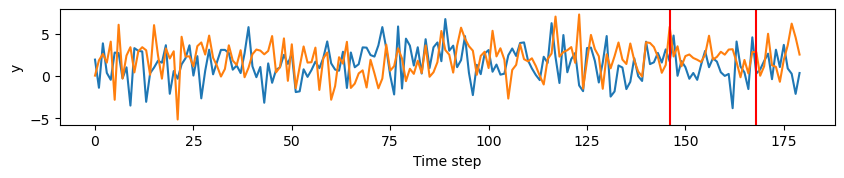

In [6]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 2, 
                        model = 'srbf', 
                        T = 1,
                        sigma = 1,
                        laplace_option = 'dirichlet',
                        laplace_hyperparameter = 1,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[ 65 117]


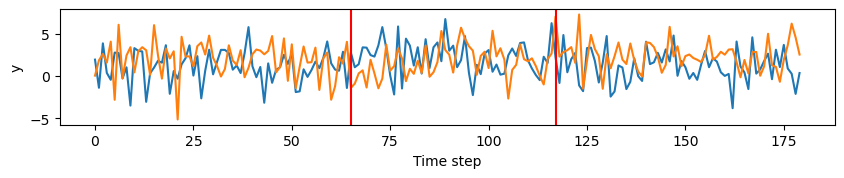

In [7]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 2, 
                        model = 'srbf', 
                        T = 2,
                        sigma = 1,
                        laplace_option = 'dirichlet',
                        laplace_hyperparameter = 1,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

[112 138]


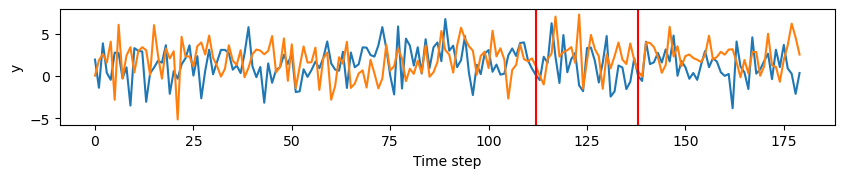

In [8]:
proposed_chpnts = binseg(sequence = y, 
                        n_changepoints = 2, 
                        model = 'srbf', 
                        T = 3,
                        sigma = 1,
                        laplace_option = 'heat',
                        laplace_hyperparameter = 2,
                        kernel_type = 'linear',
                        centered = False,
                        nonlinear_hyperparam = 1)

print(proposed_chpnts)
plt.figure(figsize=(10, 1.5))
for i in range(y.shape[1]):
    plt.plot(y[:, i])
for j in proposed_chpnts:
    plt.axvline(x = j, color='red')
plt.xlabel("Time step")
plt.ylabel("y")
plt.show()

### TESTING

In [9]:
from scipy.spatial.distance import pdist

def median_heuristic(X, kernel_type='gaussian'):
    if kernel_type == 'gaussian':
        distances = pdist(X, metric="euclidean")
        sigma = np.median(distances)
        return max(sigma, 1e-7)

    if kernel_type == 'laplace':
        distances = pdist(X, metric="cityblock")
        gamma = np.median(distances)
        return min(gamma**(-1), 1e7)

In [10]:
median_heuristic(y, kernel_type='gaussian')

np.float64(3.2485517959171823)